# 노드 3 실습

In [1]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

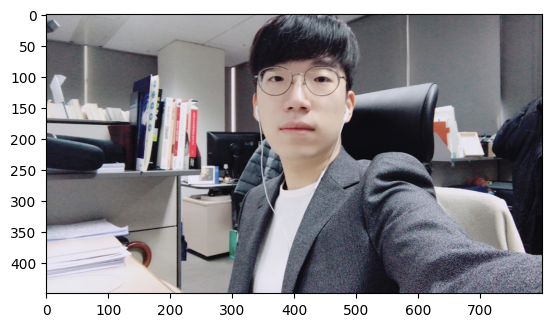

In [2]:
home_dir = os.getcwd()
img_path = os.path.join(home_dir, "images/my_image.png")
img_orig = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

/home/jhyun/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jhyun/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

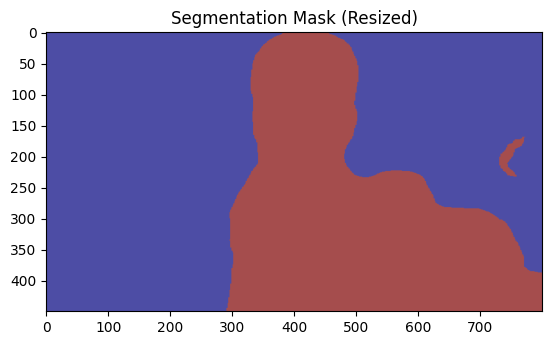

In [5]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [6]:
unique_classes = np.unique(output_predictions_resized)
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [7]:
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[15]

array([192, 128, 128])

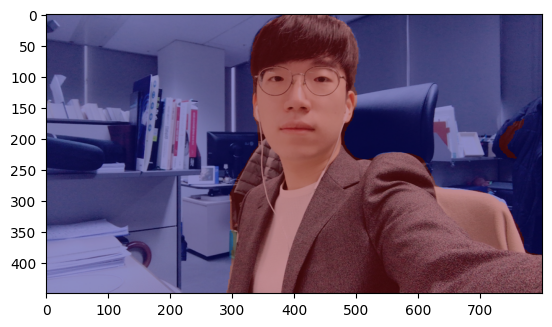

In [8]:
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

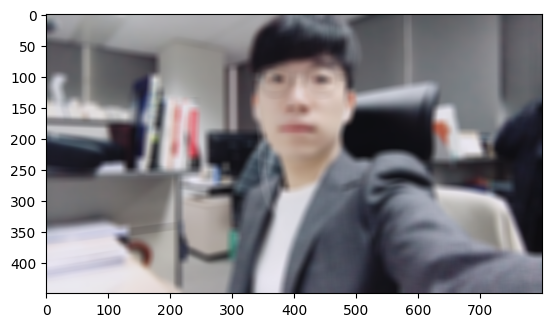

In [9]:
img_orig_blur = cv2.blur(img_orig, (13, 13))
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

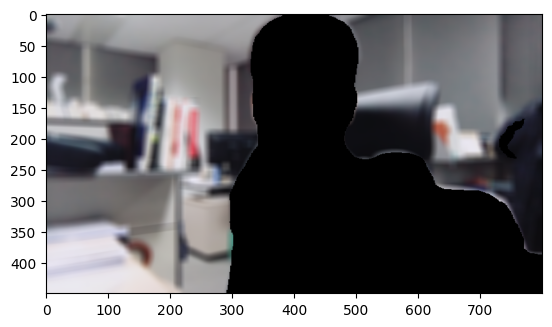

In [10]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

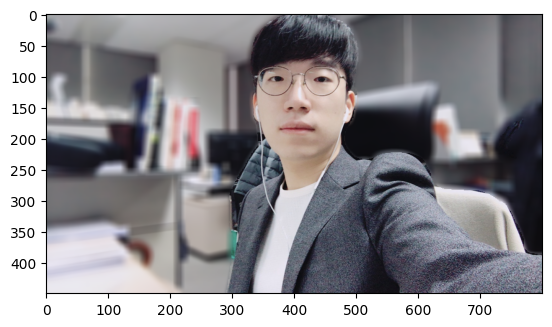

In [11]:
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

위 사진의 문제점
![](./images/p1.png)
- 배경 일부가 인물 영역에 포함
- 머리카락 경계가 깔끔하게 분리되지않아 blur처리되어 보인다

# 노드 4 : 프로젝트

## 라이브러리 & 모델 준비

In [12]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet101

In [13]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

## LABEL CLASS 정의

In [14]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

## 함수

In [15]:
def get_img(img_name):
    home_dir = os.getcwd()
    img_path = os.path.join(home_dir, 'images', img_name)
    return cv2.imread(img_path)

In [16]:
# 주어진 이미지
def segment_mask(img_bgr, target_class='person'):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img_rgb).unsqueeze(0)
    with torch.no_grad():
        output = model(input_tensor)['out'][0]
        pred = output.argmax(0).byte().cpu().numpy()

    pred_resized = cv2.resize(pred, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)

    class_id = LABEL_NAMES.index(target_class)
    mask = (pred_resized == class_id).astype(np.uint8) * 255
    return mask


In [17]:
def blur_background(img_bgr, mask):
    img_blur = cv2.blur(img_bgr, (13, 13))
    mask_color = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    img_mask = cv2.bitwise_not(mask_color)
    bg_blur = cv2.bitwise_and(img_blur, img_mask)
    img_concat = np.where(mask_color==255, img_bgr, bg_blur)
    plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
    plt.show()
    # return img_concat

In [18]:
def replace_background(img_bgr, mask, bg_img):
    bg_resized = cv2.resize(bg_img, (img_bgr.shape[1], img_bgr.shape[0]))
    mask_color = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    img_concat = np.where(mask_color == 255, img_bgr, bg_resized)
    plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
    plt.show()
    # return img_concat

## 메인 코드

In [19]:
# 이미지 설정
person_img1 = get_img('pi1.png')
person_img2 = get_img('pi2.png')
person_img3 = get_img('pi3.png')
back_img1 = get_img('bg1.png')
back_img2 = get_img('bg2.png')
cat_img = get_img('cat.png')
sand_img = get_img('sand.png')

In [20]:
# 이미지 마스킹
p1_mask = segment_mask(person_img1, 'person')
p2_mask = segment_mask(person_img2, 'person')
p3_mask = segment_mask(person_img3, 'person')
cat_mask = segment_mask(cat_img, 'cat')

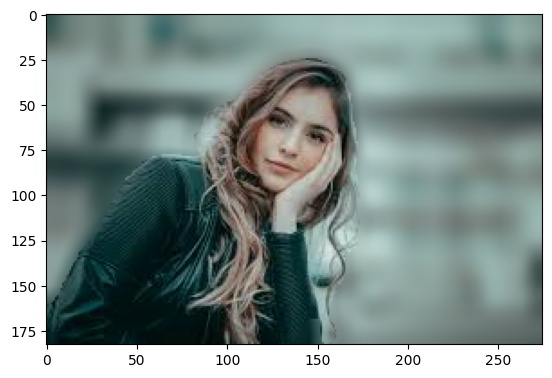

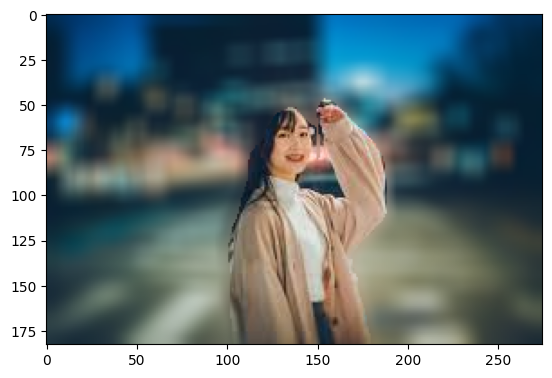

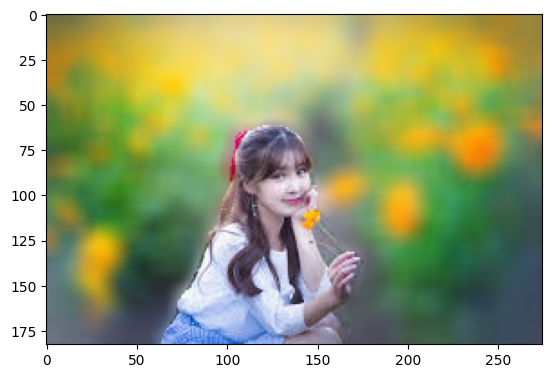

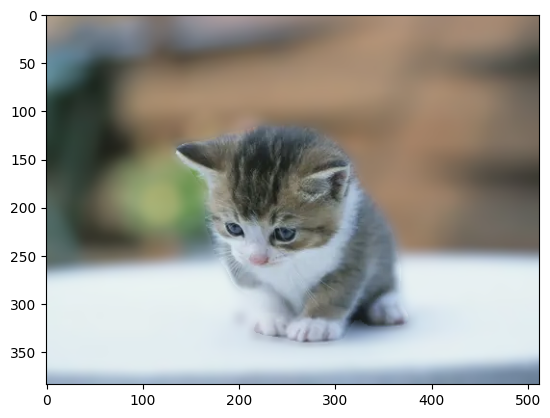

In [21]:
# blur 효과
blur_background(person_img1, p1_mask)
blur_background(person_img2, p2_mask)
blur_background(person_img3, p3_mask)
blur_background(cat_img, cat_mask)

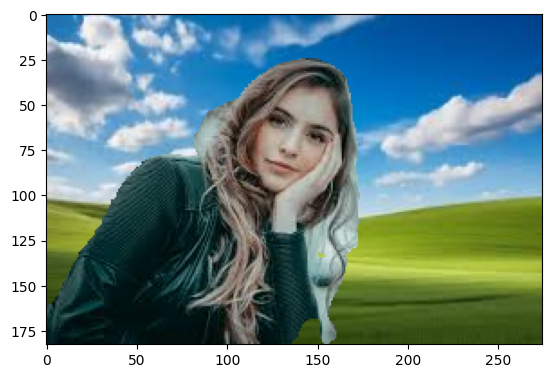

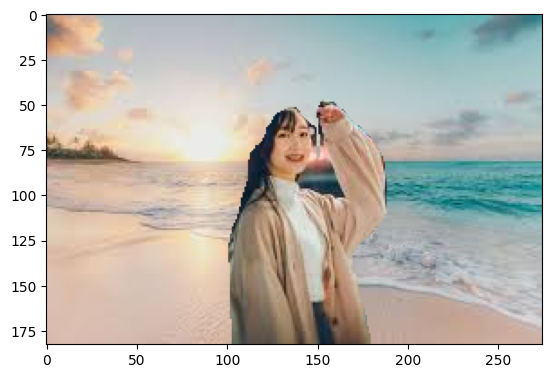

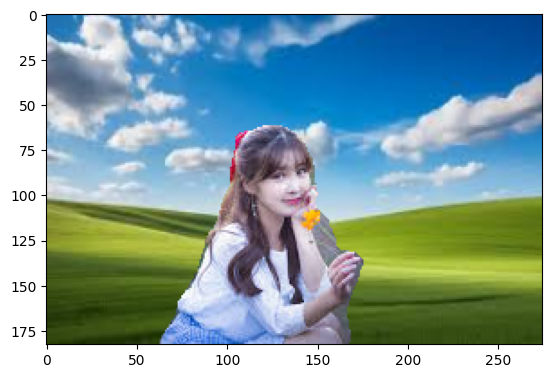

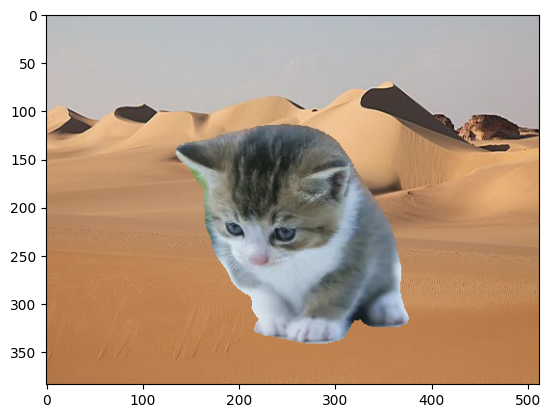

In [22]:
# 크로마키 효과
replace_background(person_img1, p1_mask, back_img1)
replace_background(person_img2, p2_mask, back_img2)
replace_background(person_img3, p3_mask, back_img1)
replace_background(cat_img, cat_mask, sand_img)

문제점
![](./images/p2.png)

##

## Step3 문제점 수정

In [23]:
def refine_mask_to_alpha(img_bgr, mask):
    # mask 경계 정제를 위한 요소 생성
    kernel = np.ones((5, 5), np.uint8)

    # 확실히 사람인 부분만 남김
    sure_fg = cv2.erode(mask, kernel, iterations=2)

    # mask의 사람 주변 배경 팽창
    sure_bg = cv2.dilate(mask, kernel, iterations=2)
    sure_bg = cv2.bitwise_not(sure_bg)

    # trimap으로 3가지 상태 확인
    trimap = np.full(mask.shape, 128, dtype=np.uint8)
    trimap[sure_fg == 255] = 255
    trimap[sure_bg == 255] = 0

    # 0~1범위 alpha로 변환
    alpha = trimap.astype(np.float32) / 255.0

    # 입력 이미지를 기준으로 경계를 부드럽게 보정
    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "guidedFilter"):
        guide = img_bgr.astype(np.float32) / 255.0
        alpha = cv2.ximgproc.guidedFilter(
            guide=guide,
            src=alpha.astype(np.float32),
            radius=8,
            eps=1e-4
        )

    # alpha의 범위를 다시 제한
    alpha = np.clip(alpha, 0, 1)

    alpha[trimap == 255] = 1.0
    alpha[trimap == 0] = 0.0

    return alpha


In [24]:
def blur_background_soft(img_bgr, alpha, ksize=21):
    # 가우시안 blur 적용
    img_blur = cv2.GaussianBlur(img_bgr, (ksize, ksize), 0)

    # alpha를 3채널로 복제
    alpha_3 = np.dstack([alpha, alpha, alpha]).astype(np.float32)

    # 원본과 blur를 alpha비율로 합성(1:원본 0:blur)
    result = img_bgr.astype(np.float32) * alpha_3 + img_blur.astype(np.float32) * (1 - alpha_3)

    # 범위를 제한
    result = np.clip(result, 0, 255).astype(np.uint8)

    # 이미지 출력
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # return result

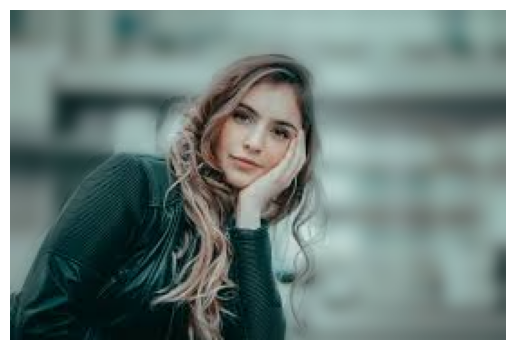

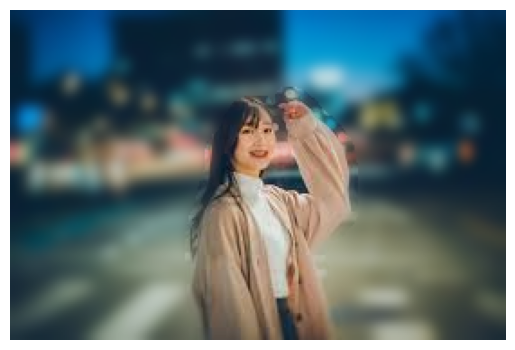

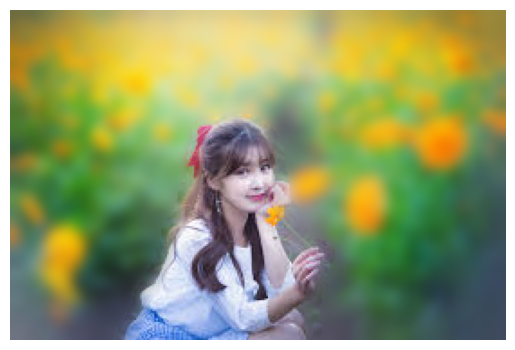

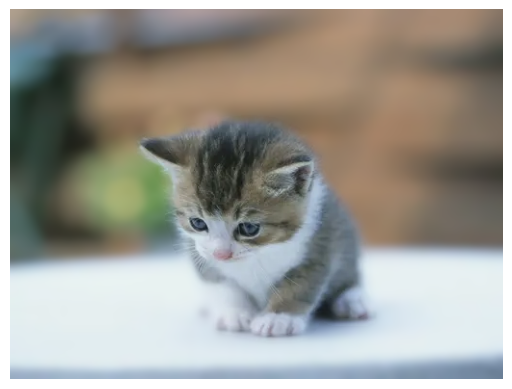

In [25]:
p1_alpha = refine_mask_to_alpha(person_img1, p1_mask)
p2_alpha = refine_mask_to_alpha(person_img2, p2_mask)
p3_alpha = refine_mask_to_alpha(person_img3, p3_mask)
cat_alpha = refine_mask_to_alpha(cat_img, cat_mask)

blur_background_soft(person_img1, p1_alpha)
blur_background_soft(person_img2, p2_alpha)
blur_background_soft(person_img3, p3_alpha)
blur_background_soft(cat_img, cat_alpha)

## 변경점
DeepLab의 semantic segmentation은 인물과 배경의 경계 부근에서 픽셀 단위 오차가 발생하여 윤곽이 끊겨 보이는 문제가 있었다.   
이를 보완하기 위해 mask의 경계 영역을 이진값이 아닌 인물과 배경, 불확실 영역 3구간으로 분리한 뒤 경계를 정제하였다.   
또한 정제된 경계는 alpha값을 이용해 원본 이미지와 blur된 배경 사이를 부드럽게 합성해 인물과 배경을 자연스럽게 이어지도록 하였다.